# Multi-asset time-series momentum with volatility targeting

Time-series momentum (Moskowitz, Ooi and Pedersen, 2012) goes long an asset whose own past return is positive and short when it is
negative, sizing each position to a constant volatility. This notebook builds a diversified test universe from **official sources**:

| assets | source | price series |
| --- | --- | --- |
| USD, GBP, JPY, CHF | ECB euro reference rates | euro value of one unit of the foreign currency ($1/X$) |
| WTI, Brent crude oil, Henry Hub natural gas | EIA spot prices (FRED) | USD spot price; non-positive prices treated as missing |
| 10-year US Treasury | Federal Reserve H.15 yield (FRED `DGS10`) | total return index of a constant-maturity par bond |

and studies

1. the baseline 12-month strategy: returns, drawdowns, contributions by asset, leverage and turnover;
2. the choice of look-back horizon;
3. a robustness grid of 104 configurations (look-back x volatility window) computed in parallel in C++;
4. in-sample selection (1999-2012) and out-of-sample evaluation (2013-2025);
5. overfitting diagnostics (PBO, deflated Sharpe ratio, bootstrap) and transaction costs;
6. a more robust design that avoids choosing a horizon: an ensemble of look-backs with a portfolio-level volatility target.

**Rules.** At the close of day $t$: $w_{t,i} = \operatorname{sign}(P_{t,i}/P_{t-L,i} - 1)\,\min(\sigma^*/\hat\sigma_{t,i}, \ell_{\max})/N_t$ with
$\hat\sigma$ an exponentially weighted volatility (centre of mass 60 days), $\sigma^* = 40\%$, $\ell_{\max} = 5$ and $N_t$ the number of
assets with a signal. Positions are executed with a one-day lag and pay 5 basis points per unit of turnover.

**Caveats.** Spot prices and spot exchange rates ignore carry, futures roll yields and funding costs; the returns are an
approximation of what futures and forwards would deliver. Series are aligned on the union of business days, with prices carried
forward over holidays for at most five days.

**Requirements.** `python -m pip install -e scripts/backtest_engine`. **Data.** Downloaded into `data/raw/`; set
`BACKTEST_ENGINE_DATA_MODE=synthetic` to run offline on simulated trending prices (not market data).

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repository root (used for data and output paths).
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "backtest_engine").is_dir())
try:
    import backtest_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "backtest_engine"))
    import backtest_engine
from backtest_engine import data, metrics as mt, strategies as st, synthetic

core = backtest_engine.require_cpp()

DATA_MODE = os.environ.get("BACKTEST_ENGINE_DATA_MODE", "official")  # "official" (ECB, EIA, Federal Reserve) or "synthetic"
START, END = "1999-01-04", "2025-12-31"
IN_SAMPLE_END = "2012-12-31"
LOOKBACK, COM = 252, 60.0      # baseline: 12-month trend, 60-day centre of mass for volatility
TARGET_VOL = 0.40              # per-asset volatility target (Moskowitz, Ooi and Pedersen, 2012)
MAX_LEVERAGE = 5.0             # cap on each asset's leverage before dividing by the number of assets
COST = 0.0005                  # 5 basis points per unit of turnover
LAG = 1
GRID_LOOKBACKS = list(range(10, 261, 10))
GRID_COMS = [20.0, 40.0, 60.0, 90.0]
WARMUP = 300                   # days before the first position can exist in every configuration
SEED = 20240517
ENSEMBLE_LOOKBACKS = [21, 63, 126, 252]   # 1, 3, 6 and 12 months, fixed a priori (not selected on the data)
PORTFOLIO_TARGET_VOL = 0.10               # annualised volatility target of the whole portfolio
PORTFOLIO_COM = 60.0                      # centre of mass (days) of the EWMA portfolio volatility estimate
MAX_SCALE = 3.0                           # cap on the portfolio scaling factor
OUTPUT_DIR = ROOT / "outputs" / "time_series_momentum"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
from backtest_engine.figstyle import MUTED, NEGATIVE, SERIES, notebook_style, ordinal_colors
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
import matplotlib.dates as mdates
from matplotlib import ticker


def plain_log_axis(ax, max_ticks=6):
    """Logarithmic y-axis with plain labels at round values (0.8, 1, 1.5, 2, 5) instead of 2x10^0."""
    ax.set_yscale("log")
    low, high = ax.get_ylim()
    decades = range(int(np.floor(np.log10(low))), int(np.ceil(np.log10(high))) + 1)
    ticks = [m * 10.0**e for e in decades for m in (1.0, 1.2, 1.5, 2.0, 3.0, 5.0, 8.0) if low <= m * 10.0**e <= high]
    while len(ticks) > max_ticks:
        ticks = ticks[::2]
    ax.yaxis.set_major_locator(ticker.FixedLocator(ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_locator(ticker.NullLocator())
print(f"backtest_engine {backtest_engine.__version__} | data mode: {DATA_MODE} | threads: {os.cpu_count()}")

backtest_engine 0.1.0 | data mode: official | threads: 4


## 1. Data

Sources:
  European Central Bank, euro foreign exchange reference rates (https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip)
  WTI crude oil spot price, Cushing, USD per barrel (EIA via FRED); Brent crude oil spot price, Europe, USD per barrel (EIA via FRED); Henry Hub natural gas spot price, USD per MMBtu (EIA via FRED)
  10-year Treasury constant-maturity yield, percent (Federal Reserve H.15 via FRED)
8 assets, 6,992 days from 1999-01-04 to 2025-12-31


,first date,annual volatility,buy-and-hold Sharpe
USD (in EUR),1999-01-04,0.0924,0.0475
GBP (in EUR),1999-01-04,0.0762,-0.0587
JPY (in EUR),1999-01-04,0.1124,-0.0464
CHF (in EUR),1999-01-04,0.0643,0.3407
WTI,1999-01-04,0.4388,0.3276
Brent,1999-01-04,0.4043,0.3371
Henry Hub,1999-01-04,1.1434,0.4538
UST 10Y TR,1999-01-04,0.0761,0.4774


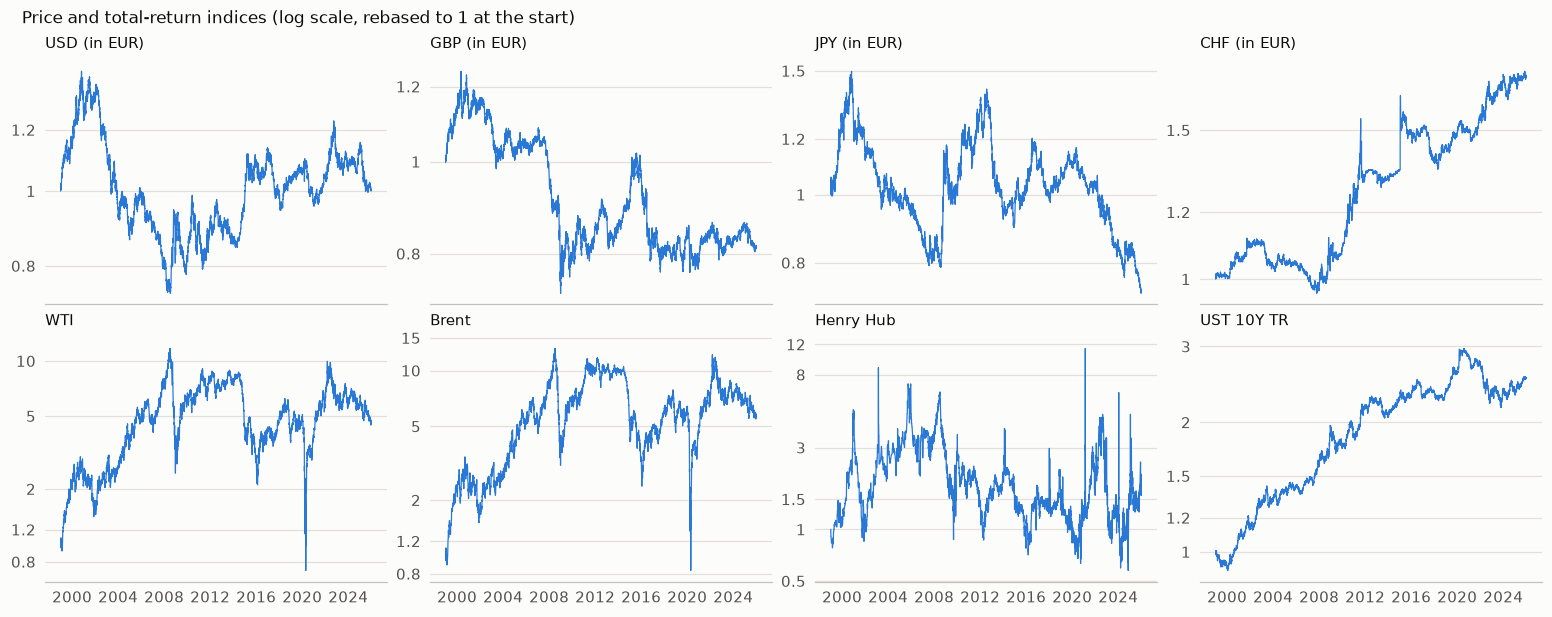

In [2]:
if DATA_MODE == "official":
    fx = data.load_ecb_fx_rates(("USD", "GBP", "JPY", "CHF"), start=START, end=END)
    energy = data.load_fred(["DCOILWTICO", "DCOILBRENTEU", "DHHNGSP"], start=START, end=END)
    blocks = [(1.0 / fx).rename(columns=lambda c: f"{c} (in EUR)"),
              energy.where(energy > 0).rename(columns={"DCOILWTICO": "WTI", "DCOILBRENTEU": "Brent", "DHHNGSP": "Henry Hub"})]
    sources = [fx.attrs["source"], energy.attrs["source"]]
    try:
        treasury = data.load_fred(["DGS10"], start=START, end=END)
        blocks.append(data.treasury_total_return_index(treasury["DGS10"]).rename("UST 10Y TR"))
        sources.append(treasury.attrs["source"])
    except OSError as err:  # FRED unreachable and no cached copy: the universe is reported without the bond
        print(f"WARNING: DGS10 not available ({err}); the Treasury total-return index is excluded from the universe.")
    prices = pd.concat(blocks, axis=1, sort=True)
else:
    prices = synthetic.trending_prices(n=7000, n_assets=8, start=START)
    sources = [prices.attrs["source"]]
prices = prices.loc[START:END].ffill(limit=5)
print("Sources:", *sources, sep="\n  ")
print(f"{prices.shape[1]} assets, {len(prices):,} days from {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}")

daily = prices.pct_change(fill_method=None)
stats = pd.DataFrame({"first date": prices.apply(lambda c: c.first_valid_index().strftime("%Y-%m-%d")),
                      "annual volatility": daily.std() * np.sqrt(252),
                      "buy-and-hold Sharpe": daily.apply(lambda c: mt.sharpe_ratio(c.dropna()))})
display(stats)
# Small multiples: eight series on one axis would need eight colours; one panel per market needs none.
rebased = prices / prices.bfill().iloc[0]
fig, axes = plt.subplots(2, 4, figsize=(14, 5.5), sharex=True)
for ax, name in zip(axes.flat, rebased.columns):
    series = rebased[name].where(rebased[name] > 0).dropna()   # log scale: WTI printed negative in April 2020
    ax.plot(series.index, series.to_numpy(), lw=0.8, color=SERIES[0])
    plain_log_axis(ax)
    ax.set_title(name, fontsize=10)
fig.suptitle("Price and total-return indices (log scale, rebased to 1 at the start)", x=0.01, ha="left", fontsize=11)
fig.savefig(OUTPUT_DIR / "universe.png", dpi=150)

## 2. Baseline strategy (12-month look-back)

Backtest in 3.4 ms (C++)


,annual mean,annual volatility,Sharpe,Sortino,max drawdown,Calmar,skewness,excess kurtosis,hit rate,observations
full sample,0.0466,0.1700,0.2740,0.4019,0.5153,0.0904,0.7712,11.6876,0.5143,"6,692.0000"
1999-2012,0.0433,0.1720,0.2518,0.3596,0.4247,0.1019,0.0938,2.3187,0.5185,"3,327.0000"
2013-2025,0.0498,0.1680,0.2966,0.4478,0.5153,0.0967,1.4893,21.8327,0.5103,"3,365.0000"


Calendar-year returns (%): {2000: 12.2, 2001: -1.2, 2002: 16.1, 2003: 23.1, 2004: -9.4, 2005: -9.3, 2006: -3.6, 2007: 12.6, 2008: 24.6, 2009: -13.1, 2010: 4.3, 2011: -2.6, 2012: -6.3, 2013: 16.5, 2014: 46.2, 2015: 31.3, 2016: -17.4, 2017: -0.1, 2018: -24.8, 2019: -1.1, 2020: 3.1, 2021: 7.0, 2022: 14.7, 2023: -8.7, 2024: -2.7, 2025: 4.8}


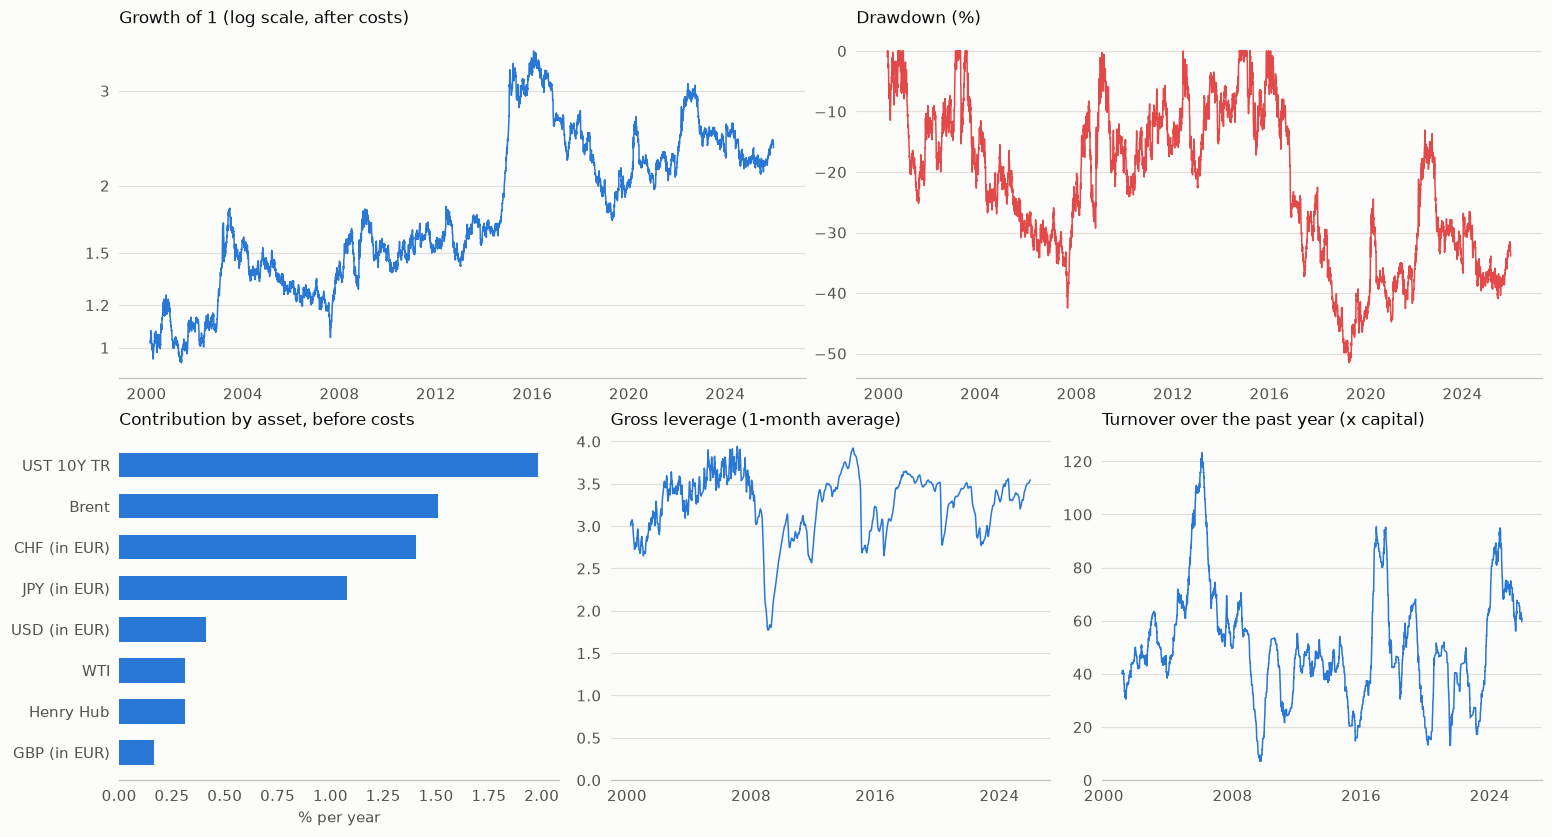

In [3]:
t0 = time.perf_counter()
base = st.tsmom_backtest(prices, LOOKBACK, COM, TARGET_VOL, MAX_LEVERAGE, COST, LAG)
print(f"Backtest in {1e3 * (time.perf_counter() - t0):.1f} ms (C++)")
r = base["returns"].iloc[WARMUP:]
in_sample = r.index <= IN_SAMPLE_END
display(pd.DataFrame({"full sample": mt.performance_summary(r), "1999-2012": mt.performance_summary(r[in_sample]),
                      "2013-2025": mt.performance_summary(r[~in_sample])}).T)

weights = base.attrs["weights"]
contrib = (weights.shift(1) * daily.fillna(0.0)).iloc[WARMUP:].sum() / (len(r) / 252)
# Leverage (about 3x) and turnover (about 50x a year) have different units: one panel each.
fig, axd = plt.subplot_mosaic([["growth"] * 3 + ["dd"] * 3, ["contrib"] * 2 + ["lev"] * 2 + ["turn"] * 2],
                              figsize=(14, 7.5))
growth = (1 + r).cumprod()
axd["growth"].plot(growth.index, growth.to_numpy(), color=SERIES[0], lw=1.0)
plain_log_axis(axd["growth"])
axd["growth"].set(title="Growth of 1 (log scale, after costs)")
axd["dd"].plot(growth.index, 100 * (growth / growth.cummax() - 1).to_numpy(), color=NEGATIVE, lw=1.0)
axd["dd"].set(title="Drawdown (%)")
ordered = (100 * contrib).sort_values()
axd["contrib"].barh(range(len(ordered)), ordered.to_numpy(), color=SERIES[0], height=0.6)
axd["contrib"].set_yticks(range(len(ordered)), ordered.index)
axd["contrib"].grid(axis="y", visible=False)
axd["contrib"].set(title="Contribution by asset, before costs", xlabel="% per year")
gross = base["gross"].iloc[WARMUP:].rolling(21).mean()
axd["lev"].plot(gross.index, gross.to_numpy(), color=SERIES[0], lw=1.0)
axd["lev"].set(title="Gross leverage (1-month average)", ylim=(0, None))
turnover = base["turnover"].iloc[WARMUP:].rolling(252).sum()
axd["turn"].plot(turnover.index, turnover.to_numpy(), color=SERIES[0], lw=1.0)
axd["turn"].set(title="Turnover over the past year (x capital)", ylim=(0, None))
for key in ("lev", "turn"):
    axd[key].xaxis.set_major_locator(mdates.YearLocator(8))
fig.savefig(OUTPUT_DIR / "baseline.png", dpi=150)
yearly = (1 + r).groupby(r.index.year).prod() - 1
print("Calendar-year returns (%):", (100 * yearly).round(1).to_dict())

## 3. Look-back horizon

In [4]:
rows = {}
for L in (21, 63, 126, 252):
    res = st.tsmom_backtest(prices, L, COM, TARGET_VOL, MAX_LEVERAGE, COST, LAG)
    s = mt.performance_summary(res["returns"].iloc[WARMUP:])
    s["annual turnover"] = res["turnover"].iloc[WARMUP:].mean() * 252
    rows[f"{L} days"] = s
display(pd.DataFrame(rows).T[["annual mean", "annual volatility", "Sharpe", "max drawdown", "skewness", "annual turnover"]])

,annual mean,annual volatility,Sharpe,max drawdown,skewness,annual turnover
21 days,-0.0563,0.1644,-0.3425,0.8687,1.1097,168.9277
63 days,-0.0164,0.1662,-0.0989,0.7231,1.0068,105.7825
126 days,0.0232,0.1667,0.1392,0.4753,0.7249,72.1846
252 days,0.0466,0.1700,0.2740,0.5153,0.7712,50.3442


## 4. Robustness grid

104 configurations: look-back from 10 to 260 days and volatility centre of mass of 20, 40, 60 or 90 days. The whole grid is a
single call to the parallel C++ engine.

104 configurations x 6,692 days in 0.07 s (C++)


Share of configurations with a positive full-sample Sharpe ratio: 55%


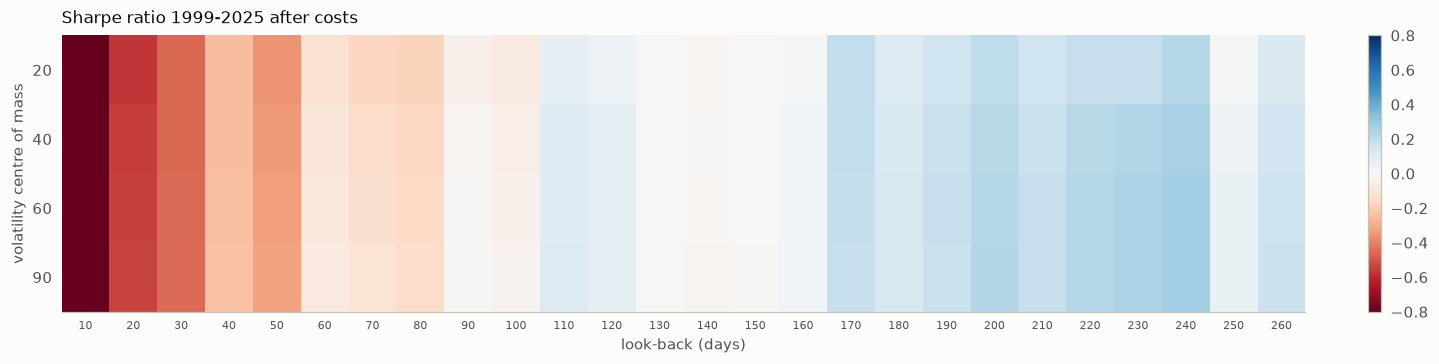

In [5]:
t0 = time.perf_counter()
grid, configs = st.tsmom_grid(prices, GRID_LOOKBACKS, GRID_COMS, TARGET_VOL, MAX_LEVERAGE, COST, LAG)
grid = grid.iloc[WARMUP:]
print(f"{grid.shape[1]} configurations x {grid.shape[0]:,} days in {time.perf_counter() - t0:.2f} s (C++)")
in_sample = grid.index <= IN_SAMPLE_END
configs["Sharpe full"] = grid.apply(mt.sharpe_ratio)
configs["Sharpe in sample"] = grid[in_sample].apply(mt.sharpe_ratio)
configs["Sharpe out of sample"] = grid[~in_sample].apply(mt.sharpe_ratio)
heat = configs.pivot(index="com", columns="lookback", values="Sharpe full")

fig, ax = plt.subplots(figsize=(13, 3.2))
im = ax.imshow(heat.to_numpy(), aspect="auto", cmap="RdBu", vmin=-0.8, vmax=0.8)
ax.set_xticks(range(len(heat.columns)), heat.columns, fontsize=7)
ax.set_yticks(range(len(heat.index)), [f"{c:g}" for c in heat.index])
ax.set(xlabel="look-back (days)", ylabel="volatility centre of mass", title="Sharpe ratio 1999-2025 after costs")
ax.grid(False)
fig.colorbar(im, ax=ax)
fig.savefig(OUTPUT_DIR / "robustness_grid.png", dpi=150)
print(f"Share of configurations with a positive full-sample Sharpe ratio: {(configs['Sharpe full'] > 0).mean():.0%}")

## 5. Selection in sample, evaluation out of sample, overfitting

In-sample winner: L=230 com=90; Sharpe 1999-2012 0.35 -> 2013-2025 0.16 (median out-of-sample Sharpe of the grid 0.02)
Correlation of in-sample and out-of-sample Sharpe ratios: 0.83


,value
"PBO (CSCV, 16 blocks)",0.3334
deflated Sharpe ratio of the winner,0.1815
expected max Sharpe of 104 trials (annualised),0.5996
out-of-sample Sharpe,0.1617
bootstrap 2.5%,-0.4107
bootstrap 97.5%,0.7154


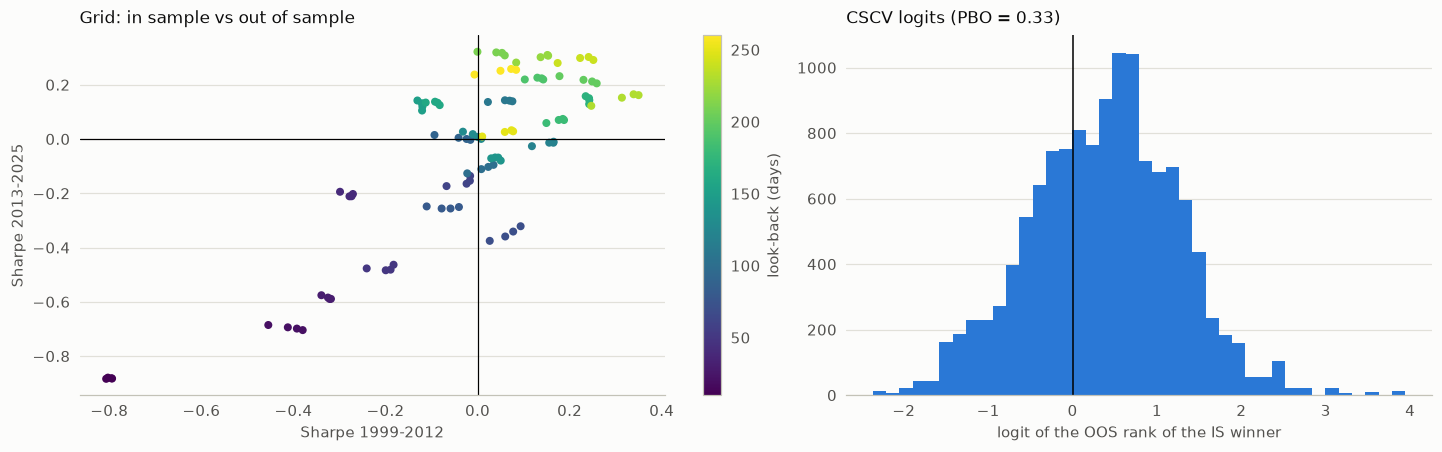

In [6]:
best = configs["Sharpe in sample"].idxmax()
print(f"In-sample winner: {best}; Sharpe 1999-2012 {configs.loc[best, 'Sharpe in sample']:.2f} -> "
      f"2013-2025 {configs.loc[best, 'Sharpe out of sample']:.2f} "
      f"(median out-of-sample Sharpe of the grid {configs['Sharpe out of sample'].median():.2f})")
print(f"Correlation of in-sample and out-of-sample Sharpe ratios: {configs['Sharpe in sample'].corr(configs['Sharpe out of sample']):.2f}")

pbo = st.probability_of_backtest_overfitting(grid, S=16)
trial_sharpes = grid[in_sample].apply(lambda c: c.mean() / c.std(ddof=1))
dsr = mt.deflated_sharpe_ratio(grid.loc[in_sample, best], trial_sharpes)
boot = mt.bootstrap_sharpe(grid.loc[~in_sample, best].to_numpy(), mean_block=20, n_boot=10_000, seed=SEED)
lo, hi = np.percentile(boot, [2.5, 97.5])
display(pd.Series({"PBO (CSCV, 16 blocks)": pbo["pbo"], "deflated Sharpe ratio of the winner": dsr["dsr"],
                   "expected max Sharpe of 104 trials (annualised)": dsr["benchmark_sharpe"] * np.sqrt(252),
                   "out-of-sample Sharpe": configs.loc[best, "Sharpe out of sample"],
                   "bootstrap 2.5%": lo, "bootstrap 97.5%": hi}, name="value").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
points = axes[0].scatter(configs["Sharpe in sample"], configs["Sharpe out of sample"], c=configs["lookback"], cmap="viridis", s=18)
fig.colorbar(points, ax=axes[0], label="look-back (days)")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set(xlabel="Sharpe 1999-2012", ylabel="Sharpe 2013-2025", title="Grid: in sample vs out of sample")
axes[1].hist(pbo["logit"], bins=40, color=SERIES[0])
axes[1].axvline(0, color="k", lw=1)
axes[1].set(title=f"CSCV logits (PBO = {pbo['pbo']:.2f})", xlabel="logit of the OOS rank of the IS winner")
fig.savefig(OUTPUT_DIR / "overfitting.png", dpi=150)

## 6. Transaction costs

In [7]:
costs = [0.0, 0.0002, 0.0005, 0.001, 0.002]
table = {}
for L in (63, 126, 252):
    table[f"{L} days"] = {f"{1e4 * c:g} bp": mt.sharpe_ratio(st.tsmom_backtest(prices, L, COM, TARGET_VOL, MAX_LEVERAGE, c, LAG)["returns"].iloc[WARMUP:])
                          for c in costs}
display(pd.DataFrame(table).T.rename_axis(columns="cost per unit of turnover"))

cost per unit of turnover,0 bp,2 bp,5 bp,10 bp,20 bp
63 days,0.2196,0.0922,-0.0989,-0.4165,-1.0458
126 days,0.3558,0.2692,0.1392,-0.0772,-0.5080
252 days,0.4224,0.3630,0.2740,0.1258,-0.1696


## 7. Horizon ensemble with a portfolio volatility target

Sections 3-5 show that the result depends on the look-back and that choosing it on the data is itself a source of overfitting.
A common industry answer is to **avoid the choice**: the signal of each asset is the average of the signs of its 1-, 3-, 6- and
12-month returns (a value between -1 and 1), fixed before looking at the results. A second layer scales the whole portfolio to a
**10% annualised volatility target**: the scaling factor decided at the close of $t$ is $\min(\sigma^*_p/\hat\sigma_{p,t}, 3)$,
where $\hat\sigma_{p,t}$ is the EWMA volatility (centre of mass 60 days) of the unscaled portfolio return up to $t$; it is executed
with the same one-day lag as the positions. Both layers are computed in C++ and tested against a Python reference implementation.

The comparison includes the in-sample grid winner of section 5, which is what a researcher selecting on 1999-2012 would have run.
Because volatility differs across variants, compare Sharpe ratios and drawdowns *relative to volatility*.

2013-2025 (out of sample)


,annual mean,annual volatility,Sharpe,max drawdown,max drawdown / volatility,worst month,skewness,"6-month vol, 10%-90% range",annual turnover
12-month (baseline),0.0498,0.1680,0.2966,0.5153,3.0672,-0.1195,1.4893,0.1235,47.8917
IS-selected (L=230 com=90),0.0273,0.1686,0.1617,0.4507,2.6726,-0.1025,1.5125,0.1251,49.6001
ensemble,-0.0115,0.1336,-0.0860,0.5709,4.2719,-0.0761,3.2460,0.1489,94.4079
ensemble + 10% vol target,-0.0050,0.1120,-0.0450,0.4412,3.9410,-0.0654,4.9075,0.0683,84.6858


1999-2025 (full sample)


,annual mean,annual volatility,Sharpe,max drawdown,max drawdown / volatility,worst month,skewness,"6-month vol, 10%-90% range",annual turnover
12-month (baseline),0.0466,0.1700,0.2740,0.5153,3.0316,-0.1195,0.7712,0.0936,50.3442
IS-selected (L=230 com=90),0.0432,0.1692,0.2555,0.4507,2.6645,-0.1025,0.8428,0.0943,51.7594
ensemble,0.0017,0.1325,0.0129,0.5709,4.3070,-0.0897,1.6424,0.0847,95.3273
ensemble + 10% vol target,0.0017,0.1078,0.0161,0.4412,4.0922,-0.0654,2.7272,0.0465,84.8296


Ensemble + vol target, out-of-sample Sharpe -0.05, 95% stationary-bootstrap interval [-0.69, 0.52] (seed 20240517)
Largest daily move of the vol-targeted ensemble: +16.93% on 2024-01-12, mainly from Henry Hub (+17.37%): a jump that no ex-ante volatility estimate can anticipate.


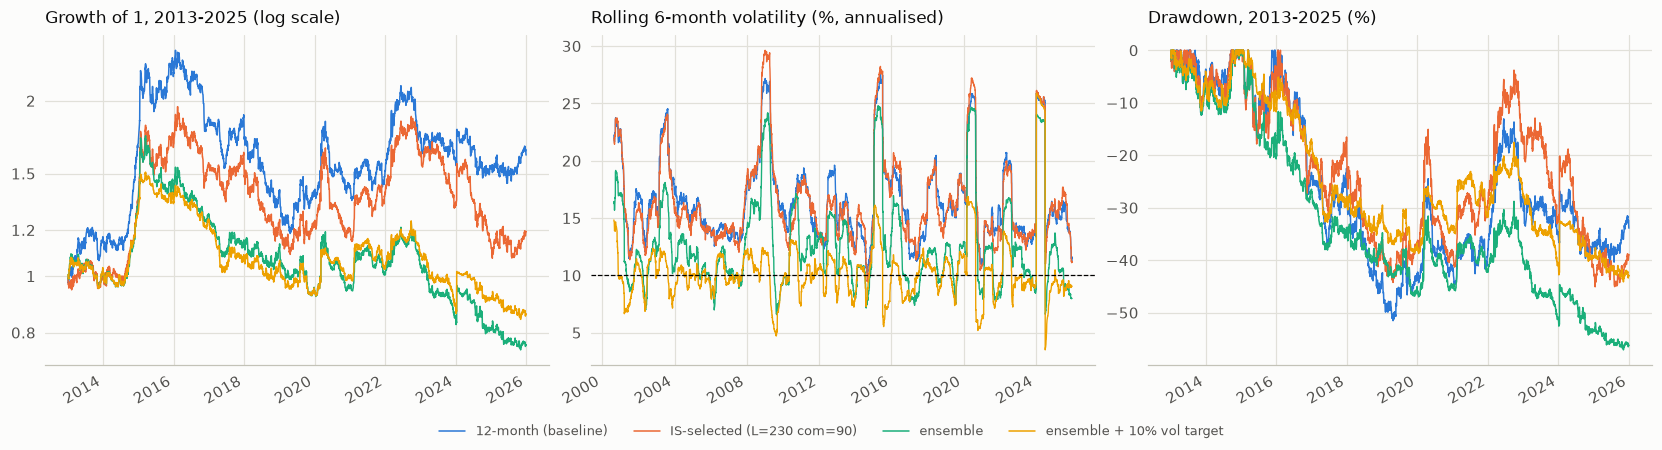

In [8]:
ensemble = st.tsmom_ensemble(prices, ENSEMBLE_LOOKBACKS, COM, TARGET_VOL, MAX_LEVERAGE, COST, LAG)
ensemble_vt = st.tsmom_ensemble(prices, ENSEMBLE_LOOKBACKS, COM, TARGET_VOL, MAX_LEVERAGE, COST, LAG,
                                portfolio_target_vol=PORTFOLIO_TARGET_VOL, portfolio_com=PORTFOLIO_COM, max_scale=MAX_SCALE)
best_row = configs.loc[best]
selected = st.tsmom_backtest(prices, int(best_row["lookback"]), float(best_row["com"]), TARGET_VOL, MAX_LEVERAGE, COST, LAG)
variants = {"12-month (baseline)": base, f"IS-selected ({best})": selected, "ensemble": ensemble,
            "ensemble + 10% vol target": ensemble_vt}
rets = pd.DataFrame({k: v["returns"] for k, v in variants.items()}).iloc[WARMUP:]
oos = rets.index > IN_SAMPLE_END

def describe(r, turnover):
    s = mt.performance_summary(r)
    rolling_vol = (r.rolling(126).std() * np.sqrt(252)).dropna()
    return {"annual mean": s["annual mean"], "annual volatility": s["annual volatility"], "Sharpe": s["Sharpe"],
            "max drawdown": s["max drawdown"], "max drawdown / volatility": s["max drawdown"] / s["annual volatility"],
            "worst month": (1 + r).resample("ME").prod().min() - 1, "skewness": s["skewness"],
            "6-month vol, 10%-90% range": rolling_vol.quantile(0.9) - rolling_vol.quantile(0.1), "annual turnover": turnover.mean() * 252}

for label, mask in (("2013-2025 (out of sample)", oos), ("1999-2025 (full sample)", np.ones(len(rets), bool))):
    table = pd.DataFrame({k: describe(rets.loc[mask, k], variants[k]["turnover"].iloc[WARMUP:][mask]) for k in rets}).T
    print(label)
    display(table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = dict(zip(rets.columns, SERIES))
(1 + rets[oos]).cumprod().plot(ax=axes[0], lw=1.0, color=colors, legend=False)
plain_log_axis(axes[0])
axes[0].set(title="Growth of 1, 2013-2025 (log scale)", xlabel="")
(100 * rets.rolling(126).std() * np.sqrt(252)).plot(ax=axes[1], lw=0.9, color=colors, legend=False)
axes[1].axhline(100 * PORTFOLIO_TARGET_VOL, color="k", ls="--", lw=0.8)
axes[1].set(title="Rolling 6-month volatility (%, annualised)", xlabel="")
wealth = (1 + rets[oos]).cumprod()
(100 * (wealth / wealth.cummax() - 1)).plot(ax=axes[2], lw=1.0, color=colors, legend=False)
axes[2].set(title="Drawdown, 2013-2025 (%)", xlabel="")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=len(rets.columns))
fig.savefig(OUTPUT_DIR / "ensemble_vol_target.png", dpi=150)

boot = mt.bootstrap_sharpe(rets.loc[oos, "ensemble + 10% vol target"].to_numpy(), mean_block=20, n_boot=10_000, seed=SEED)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Ensemble + vol target, out-of-sample Sharpe {mt.sharpe_ratio(rets.loc[oos, 'ensemble + 10% vol target']):.2f}, "
      f"95% stationary-bootstrap interval [{lo:.2f}, {hi:.2f}] (seed {SEED})")
vt = rets["ensemble + 10% vol target"]
day = vt.abs().idxmax()
held = ensemble_vt.attrs["weights"].shift(1).loc[day]
contribution = (held * daily.loc[day]).dropna()
print(f"Largest daily move of the vol-targeted ensemble: {vt[day]:+.2%} on {day:%Y-%m-%d}, mainly from "
      f"{contribution.abs().idxmax()} ({contribution[contribution.abs().idxmax()]:+.2%}): a jump that no ex-ante volatility "
      "estimate can anticipate.")
rets.to_csv(OUTPUT_DIR / "variant_returns.csv")

## 8. Interpretation guide

- Time-series momentum is a slow strategy: its performance comes in bursts during persistent trends and suffers in choppy markets.
  Positive skewness of daily returns is typical; long losing streaks are too.
- This universe is small and energy-heavy, and spot series ignore carry and roll yield, so results can differ markedly from the
  diversified futures universes studied in the literature (Moskowitz, Ooi and Pedersen, 2012; Hurst, Ooi and Pedersen, 2017).
- The heat map shows how sensitive the Sharpe ratio is to the look-back and volatility windows. A robust effect should appear as a broad
  region of similar colour, not as an isolated hot spot.
- A PBO close to or above 0.5, a low deflated Sharpe ratio and a bootstrap interval that includes zero mean that the grid search has not
  produced statistically reliable evidence of skill, whatever the best in-sample Sharpe ratio looks like.
- The ensemble does not need a horizon to be chosen, so it carries no selection bias; the portfolio volatility target stabilises risk
  over time, which is what a risk budget or a mandate limit requires. Neither is a source of return by itself: they make the
  outcome less dependent on one parameter and on one volatility regime. If the short horizons lose money after costs in a given
  universe (section 3), an equal-weight ensemble inherits those losses: removing the selection risk does not remove the need to
  check that every component is economically sound.
- Volatility targeting reacts to volatility after it has appeared: overnight jumps (in energy spot prices, for example) still pass
  through at full size, so limits based on realised volatility must be complemented by stress tests and position limits.
- The variant returns are saved to `outputs/time_series_momentum/variant_returns.csv` and feed the multi-strategy case study.

Figures are saved in `outputs/time_series_momentum/`.

### References

- Bailey, D. H., Borwein, J., Lopez de Prado, M. and Zhu, Q. J. (2017). The probability of backtest overfitting. *Journal of Computational Finance*, 20(4), 39-69.
- Bailey, D. H. and Lopez de Prado, M. (2014). The deflated Sharpe ratio. *Journal of Portfolio Management*, 40(5), 94-107.
- Board of Governors of the Federal Reserve System, H.15 Selected Interest Rates, 10-year Treasury constant maturity (FRED `DGS10`).
- European Central Bank, euro foreign exchange reference rates.
- Hurst, B., Ooi, Y. H. and Pedersen, L. H. (2017). A century of evidence on trend-following investing. *Journal of Portfolio Management*, 44(1), 15-29.
- Lo, A. W. (2002). The statistics of Sharpe ratios. *Financial Analysts Journal*, 58(4), 36-52.
- Moskowitz, T. J., Ooi, Y. H. and Pedersen, L. H. (2012). Time series momentum. *Journal of Financial Economics*, 104(2), 228-250.
- Politis, D. N. and Romano, J. P. (1994). The stationary bootstrap. *Journal of the American Statistical Association*, 89(428), 1303-1313.
- U.S. Energy Information Administration, spot prices of crude oil and natural gas (FRED `DCOILWTICO`, `DCOILBRENTEU`, `DHHNGSP`).